In [8]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import os
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data"
OUT_DIR  = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Model data"
os.makedirs(OUT_DIR, exist_ok=True)

# ── STEP 1: Load all raw files ───────────────────────────────────────────────

def load(filename, date_col="Date", **kwargs):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, **kwargs)
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col).sort_index()
    return df

# Daily factors
icici      = load("icici_bank_daily.csv")[["Close"]]
nifty      = load("nifty50_daily.csv")[["Close"]]
bank_nifty = load("bank_nifty_daily.csv")[["Close"]]
gold       = load("gold_daily.csv")[["Close"]]
usd_inr    = load("usd_inr_daily.csv")[["USD_INR"]]
bond_10y   = load("India 10-Year Bond Yield Historical Data.csv")[["Price"]]
bond_5y    = load("India 5-Year Bond Yield Historical Data.csv")[["Price"]]
us_bonds   = load("us_bond_yields.csv")[["US_10Y", "US_5Y"]]
fii_dii    = load("fii_dii_2018_to_2026.csv")[["FII_Net", "DII_Net"]]

# Monthly factors
cpi_wpi    = load("india_cpi_wpi_monthly.csv")[["CPI_Index", "WPI_Index"]]
trade      = load("india_trade_data_monthly.csv")[["Trade_Balance_Billion_USD"]]
rbi        = load("rbi_policy_rates.csv")[["Repo_Rate_%", "CRR_%"]]

# Quarterly factors
gdp        = load("india_gdp_quarterly.csv")[["Real_GDP_YoY_Growth_%"]]

# ── STEP 2: Fix ICICI Quarterly Results date ─────────────────────────────────

def fix_icici_quarterly():
    df = pd.read_csv(os.path.join(DATA_DIR, 
         "ICICI_Bank_Quarterly_Results_FY2010_FY2026 copy.csv"))
    
    quarter_map = {"Q1": "04", "Q2": "07", "Q3": "10", "Q4": "01"}
    
    def to_date(row):
        fy   = str(row["Fiscal Year"])        
        q    = str(row["Quarter"])            
        year = int(fy.replace("FY", ""))
        month = quarter_map.get(q, "01")
        if q == "Q4":                            # Q4 is Jan of NEXT FY
            year += 1
        return pd.Timestamp(f"{year}-{month}-01")
    
    df["Date"] = df.apply(to_date, axis=1)
    df = df.set_index("Date").sort_index()
    return df[["Net Profit (₹ Cr)", "NII (₹ Cr)"]]

icici_quarterly = fix_icici_quarterly()

# ── STEP 3: Master daily calendar + forward-fill ─────────────────────────────

# Use 2010-2026, trading days only (Mon-Fri)
master_index = pd.bdate_range(start="2010-01-04", end="2026-05-11")

def to_daily(df, method="ffill"):
    return (df
            .reindex(master_index)
            .fillna(method="ffill")   # carry last known value forward
            .fillna(method="bfill"))  # backfill for any leading NaNs

# Daily — just reindex
icici_d      = to_daily(icici)
nifty_d      = to_daily(nifty)
bank_nifty_d = to_daily(bank_nifty)
gold_d       = to_daily(gold)
usd_inr_d    = to_daily(usd_inr)
bond_10y_d   = to_daily(bond_10y)
bond_5y_d    = to_daily(bond_5y)
us_bonds_d   = to_daily(us_bonds)
fii_dii_d    = to_daily(fii_dii)   # will have NaN before 2018

# Monthly/Quarterly — forward-fill onto daily (this IS the MIDAS alignment)
cpi_wpi_d        = to_daily(cpi_wpi)
trade_d          = to_daily(trade)
rbi_d            = to_daily(rbi)
gdp_d            = to_daily(gdp)
icici_qtrly_d    = to_daily(icici_quarterly)

# ── STEP 4: Merge into master frame ─────────────────────────────────────────

master = pd.concat([
    icici_d.rename(columns={"Close": "ICICI_Close"}),
    nifty_d.rename(columns={"Close": "Nifty_Close"}),
    bank_nifty_d.rename(columns={"Close": "BankNifty_Close"}),
    gold_d.rename(columns={"Close": "Gold_Close"}),
    usd_inr_d,
    bond_10y_d.rename(columns={"Price": "Bond_10Y"}),
    bond_5y_d.rename(columns={"Price": "Bond_5Y"}),
    us_bonds_d,
    fii_dii_d,
    cpi_wpi_d,
    trade_d,
    rbi_d,
    gdp_d,
    icici_qtrly_d,
], axis=1)

print(f"Master shape: {master.shape}")
print(f"Date range : {master.index[0].date()} → {master.index[-1].date()}")
print(f"\nMissing values per column:\n{master.isnull().sum()}")

# ── STEP 5: Convert to RETURNS (critical for stationarity) ──────────────────

# Price-like columns → log returns
price_cols = [
    "ICICI_Close", "Nifty_Close", "BankNifty_Close",
    "Gold_Close", "USD_INR", "Bond_10Y", "Bond_5Y",
    "US_10Y", "US_5Y"
]

# Rate/flow columns → simple difference (already stationary or near)
diff_cols = [
    "FII_Net", "DII_Net", "CPI_Index", "WPI_Index",
    "Trade_Balance_Billion_USD", "Repo_Rate_%", "CRR_%",
    "Real_GDP_YoY_Growth_%", "Net Profit (₹ Cr)", "NII (₹ Cr)"
]

master_ret = pd.DataFrame(index=master.index)

for col in price_cols:
    if col in master.columns:
        master_ret[col + "_ret"] = np.log(master[col] / master[col].shift(1))

for col in diff_cols:
    if col in master.columns:
        master_ret[col + "_chg"] = master[col].diff()

master_ret = master_ret.dropna(how="all")

# ── STEP 6: Winsorize outliers at 3σ ────────────────────────────────────────

def winsorize(df, n_std=3):
    clipped = df.copy()
    for col in df.columns:
        mean = df[col].mean()
        std  = df[col].std()
        clipped[col] = df[col].clip(lower=mean - n_std*std,
                                    upper=mean + n_std*std)
    return clipped

master_clean = winsorize(master_ret)

# ── STEP 7: ADF stationarity test ────────────────────────────────────────────

print("\n── Stationarity Check (ADF Test) ──")
print(f"{'Column':<35} {'p-value':>10} {'Stationary?':>12}")
print("-" * 60)

for col in master_clean.columns:
    series = master_clean[col].dropna()
    if len(series) < 30:
        continue
    pval = adfuller(series, autolag="AIC")[1]
    flag = "✅ YES" if pval < 0.05 else "❌ NO"
    print(f"{col:<35} {pval:>10.4f} {flag:>12}")

# ── STEP 8: Save ─────────────────────────────────────────────────────────────

master_clean.to_csv(os.path.join(OUT_DIR, "master_clean.csv"))
master.to_csv(os.path.join(OUT_DIR, "master_raw_aligned.csv"))

print(f"\n✅ Saved to {OUT_DIR}")
print(f"   master_clean.csv     — returns, winsorized, ready for model")
print(f"   master_raw_aligned.csv — raw aligned daily (for reference)")

Master shape: (4266, 19)
Date range : 2010-01-04 → 2026-05-11

Missing values per column:
ICICI_Close                  0
Nifty_Close                  0
BankNifty_Close              0
Gold_Close                   0
USD_INR                      0
Bond_10Y                     0
Bond_5Y                      0
US_10Y                       0
US_5Y                        0
FII_Net                      0
DII_Net                      0
CPI_Index                    0
WPI_Index                    0
Trade_Balance_Billion_USD    0
Repo_Rate_%                  0
CRR_%                        0
Real_GDP_YoY_Growth_%        0
Net Profit (₹ Cr)            0
NII (₹ Cr)                   0
dtype: int64

── Stationarity Check (ADF Test) ──
Column                                 p-value  Stationary?
------------------------------------------------------------
ICICI_Close_ret                         0.0000        ✅ YES
Nifty_Close_ret                         0.0000        ✅ YES
BankNifty_Close_ret           

Features : 18
Samples  : 4264
Date range: 2010-01-05 → 2026-05-08

Feature columns:
   1. Nifty_Close_ret
   2. BankNifty_Close_ret
   3. Gold_Close_ret
   4. USD_INR_ret
   5. Bond_10Y_ret
   6. Bond_5Y_ret
   7. US_10Y_ret
   8. US_5Y_ret
   9. FII_Net_chg
  10. DII_Net_chg
  11. CPI_Index_chg
  12. WPI_Index_chg
  13. Trade_Balance_Billion_USD_chg
  14. Repo_Rate_%_chg
  15. CRR_%_chg
  16. Real_GDP_YoY_Growth_%_chg
  17. Net Profit (₹ Cr)_chg
  18. NII (₹ Cr)_chg

Train: 2010-01-05 → 2023-01-31 (3411 days)
Test : 2023-02-01  → 2026-05-08  (853 days)

── Model Performance ──
OLS   R²: -0.0100
Ridge R²: -0.0100
(Baseline R²=0 means no predictive power; >0.05 is meaningful for daily returns)

── Factor Weights (β) — sorted by importance ──
Factor                                     β weight    Direction
-----------------------------------------------------------------
Nifty_Close_ret                            -0.00185    ↓ Bearish
BankNifty_Close_ret                         0.00153  

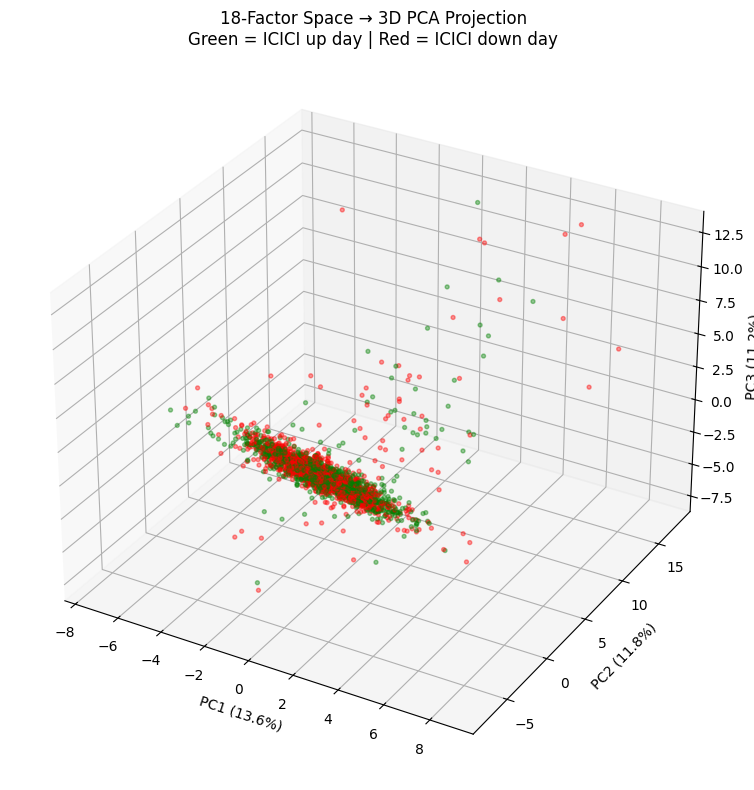


✅ 3D plot saved to Model data/pca_3d_factor_space.png
✅ factor_weights.csv saved
✅ pca_loadings.csv saved


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

OUT_DIR = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Model data"

# ── STEP 1: Load & define X, y ───────────────────────────────────────────────

df = pd.read_csv(f"{OUT_DIR}/master_clean.csv", index_col=0, parse_dates=True)

# Target: ICICI next day return (shift -1 = predict tomorrow using today's factors)
df["target"] = df["ICICI_Close_ret"].shift(-1)
df = df.dropna()

# Features: everything except ICICI return itself (that would be leakage)
feature_cols = [c for c in df.columns if c != "target" and c != "ICICI_Close_ret"]

X = df[feature_cols]
y = df["target"]

print(f"Features : {len(feature_cols)}")
print(f"Samples  : {len(X)}")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}\n")
print("Feature columns:")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {c}")

# ── STEP 2: Train / Test split (time-aware, no shuffle) ──────────────────────

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"\nTrain: {X_train.index[0].date()} → {X_train.index[-1].date()} ({len(X_train)} days)")
print(f"Test : {X_test.index[0].date()}  → {X_test.index[-1].date()}  ({len(X_test)} days)")

# ── STEP 3: Scale features ────────────────────────────────────────────────────

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── STEP 4: Linear Regression + Ridge ────────────────────────────────────────

# Plain OLS first
ols = LinearRegression()
ols.fit(X_train_sc, y_train)
ols_pred = ols.predict(X_test_sc)
ols_r2   = r2_score(y_test, ols_pred)

# Ridge (regularized — more stable for many correlated factors)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
ridge_pred = ridge.predict(X_test_sc)
ridge_r2   = r2_score(y_test, ridge_pred)

print(f"\n── Model Performance ──")
print(f"OLS   R²: {ols_r2:.4f}")
print(f"Ridge R²: {ridge_r2:.4f}")
print(f"(Baseline R²=0 means no predictive power; >0.05 is meaningful for daily returns)")

# ── STEP 5: Factor weights (β coefficients) ───────────────────────────────────

weights = pd.Series(ridge.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

print(f"\n── Factor Weights (β) — sorted by importance ──")
print(f"{'Factor':<40} {'β weight':>10} {'Direction':>12}")
print("-" * 65)
for factor, w in weights.items():
    direction = "↑ Bullish" if w > 0 else "↓ Bearish"
    print(f"{factor:<40} {w:>10.5f} {direction:>12}")

# ── STEP 6: PCA — compress 18D → 3D for visualization ────────────────────────

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_sc)

explained = pca.explained_variance_ratio_
print(f"\n── PCA: Variance Explained ──")
print(f"PC1: {explained[0]*100:.1f}%")
print(f"PC2: {explained[1]*100:.1f}%")
print(f"PC3: {explained[2]*100:.1f}%")
print(f"Total (3 components): {sum(explained)*100:.1f}%")

# Eigenvalues per factor (loading magnitudes on PC1)
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2", "PC3"]
)
loadings["eigenvalue_contribution"] = loadings["PC1"].abs()
loadings = loadings.sort_values("eigenvalue_contribution", ascending=False)

print(f"\n── Factor Loadings on PC1 (dominant axis) ──")
print(f"{'Factor':<40} {'PC1 Loading':>12}")
print("-" * 55)
for factor, row in loadings.iterrows():
    print(f"{factor:<40} {row['PC1']:>12.4f}")

# ── STEP 7: 3D PCA Plot ───────────────────────────────────────────────────────

# Color by ICICI return direction
colors = ["green" if r > 0 else "red" for r in y_train]

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=colors, alpha=0.4, s=8
)

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({explained[2]*100:.1f}%)")
ax.set_title("18-Factor Space → 3D PCA Projection\nGreen = ICICI up day | Red = ICICI down day")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pca_3d_factor_space.png", dpi=150)
plt.show()
print(f"\n✅ 3D plot saved to Model data/pca_3d_factor_space.png")

# ── STEP 8: Save model outputs ────────────────────────────────────────────────

weights.to_csv(f"{OUT_DIR}/factor_weights.csv", header=True)
loadings.to_csv(f"{OUT_DIR}/pca_loadings.csv")

print("✅ factor_weights.csv saved")
print("✅ pca_loadings.csv saved")

Building lagged + rolling features...
Composite indices added: RiskStress, MacroHealth, Liquidity, Momentum

Total features after engineering : 102
Samples after dropna             : 4204

── Ridge α sweep ──
     Alpha   Train R²    Test R²
-----------------------------------
      0.01     0.0401    -0.0455
      0.10     0.0401    -0.0455
      1.00     0.0401    -0.0454
     10.00     0.0401    -0.0441
    100.00     0.0389    -0.0362

Best alpha: 100.0 → Test R²: -0.0362

── Top 20 Features by Importance ──
Feature                                         β weight  Direction
--------------------------------------------------------------------
US_10Y_ret_lag1                                  0.00151          ↑
Nifty_Close_ret_lag1                            -0.00151          ↓
Nifty_Close_ret_lag10                           -0.00148          ↓
BankNifty_Close_ret_roll10m                     -0.00137          ↓
Nifty_Close_ret_lag5                            -0.00128          ↓
Bond_

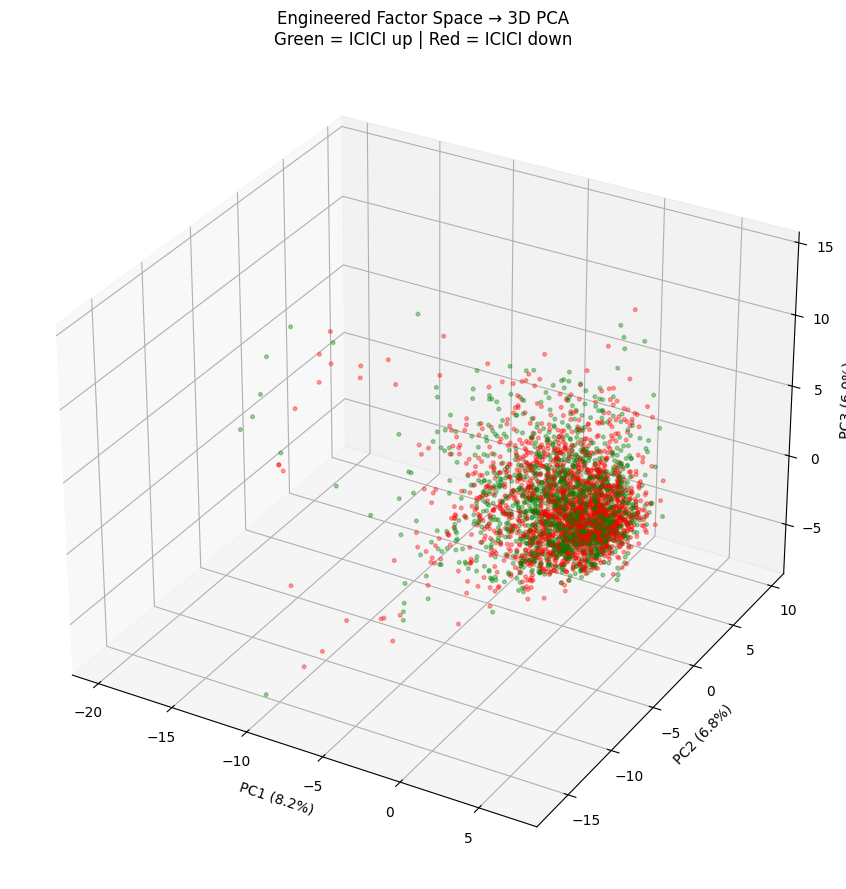


── Direction Accuracy ──
Did model predict UP/DOWN correctly? 45.66%
(Random baseline = 50%. >53% is meaningful for daily returns)

✅ master_engineered.csv saved (4204 rows, 102 features)
✅ factor_weights_engineered.csv saved


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

OUT_DIR = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Model data"

# ── STEP 1: Load clean data ───────────────────────────────────────────────────

df = pd.read_csv(f"{OUT_DIR}/master_clean.csv", index_col=0, parse_dates=True)

# Raw factor columns (no ICICI — avoid leakage)
factor_cols = [c for c in df.columns if c != "ICICI_Close_ret"]

# ── STEP 2: Engineer lagged + rolling features ────────────────────────────────

print("Building lagged + rolling features...")
features = pd.DataFrame(index=df.index)

# Daily factors get full lag + rolling treatment
daily_cols = [
    "Nifty_Close_ret", "BankNifty_Close_ret", "Gold_Close_ret",
    "USD_INR_ret", "Bond_10Y_ret", "Bond_5Y_ret",
    "US_10Y_ret", "US_5Y_ret", "FII_Net_chg", "DII_Net_chg"
]

# Slow factors (monthly/quarterly) — only current value, no lags needed
slow_cols = [
    "CPI_Index_chg", "WPI_Index_chg", "Trade_Balance_Billion_USD_chg",
    "Repo_Rate_%_chg", "CRR_%_chg", "Real_GDP_YoY_Growth_%_chg",
    "Net Profit (₹ Cr)_chg", "NII (₹ Cr)_chg"
]

# Lags: t-1, t-2, t-5, t-10 for daily factors
for col in daily_cols:
    for lag in [1, 2, 5, 10]:
        features[f"{col}_lag{lag}"] = df[col].shift(lag)

# Rolling mean: 5d, 10d, 20d for daily factors
for col in daily_cols:
    for window in [5, 10, 20]:
        features[f"{col}_roll{window}m"] = df[col].shift(1).rolling(window).mean()

# Rolling std (volatility): 5d, 10d for daily factors
for col in daily_cols:
    for window in [5, 10]:
        features[f"{col}_roll{window}std"] = df[col].shift(1).rolling(window).std()

# Slow factors — just current value
for col in slow_cols:
    features[col] = df[col]

# ── STEP 3: Composite Regime Indices ─────────────────────────────────────────

def zscore(series, window=60):
    """Rolling z-score to normalize regime signals"""
    mean = series.shift(1).rolling(window).mean()
    std  = series.shift(1).rolling(window).std()
    return (series - mean) / (std + 1e-9)

# Risk Stress Index: high = stressed market (bad for ICICI)
features["RiskStress_idx"] = (
    zscore(df["USD_INR_ret"])
    - zscore(df["FII_Net_chg"])
    + zscore(df["Bond_10Y_ret"]).abs()
)

# Macro Health Index: high = strong macro (good for ICICI)
features["MacroHealth_idx"] = (
    - zscore(df["CPI_Index_chg"])
    - zscore(df["WPI_Index_chg"])
    + zscore(df["Real_GDP_YoY_Growth_%_chg"])
    - zscore(df["Trade_Balance_Billion_USD_chg"])
)

# Liquidity Index: high = loose liquidity (good for banks)
features["Liquidity_idx"] = (
    - zscore(df["Repo_Rate_%_chg"])
    + zscore(df["DII_Net_chg"])
    + zscore(df["FII_Net_chg"])
)

# Market Momentum Index
features["Momentum_idx"] = (
    zscore(df["Nifty_Close_ret"])
    + zscore(df["BankNifty_Close_ret"])
    - zscore(df["USD_INR_ret"])
)

print(f"Composite indices added: RiskStress, MacroHealth, Liquidity, Momentum")

# ── STEP 4: Target + clean ────────────────────────────────────────────────────

features["target"] = df["ICICI_Close_ret"].shift(-1)
features = features.replace([np.inf, -np.inf], np.nan).dropna()

feature_cols = [c for c in features.columns if c != "target"]
X = features[feature_cols]
y = features["target"]

print(f"\nTotal features after engineering : {len(feature_cols)}")
print(f"Samples after dropna             : {len(X)}")

# ── STEP 5: Train/test split ──────────────────────────────────────────────────

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ── STEP 6: Scale + Ridge ─────────────────────────────────────────────────────

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Try multiple Ridge alphas
print("\n── Ridge α sweep ──")
print(f"{'Alpha':>10} {'Train R²':>10} {'Test R²':>10}")
print("-" * 35)
best_alpha, best_r2 = 1.0, -999
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    m = Ridge(alpha=alpha)
    m.fit(X_train_sc, y_train)
    tr2 = r2_score(y_train, m.predict(X_train_sc))
    te2 = r2_score(y_test,  m.predict(X_test_sc))
    print(f"{alpha:>10.2f} {tr2:>10.4f} {te2:>10.4f}")
    if te2 > best_r2:
        best_r2, best_alpha = te2, alpha

print(f"\nBest alpha: {best_alpha} → Test R²: {best_r2:.4f}")

# Fit best model
model = Ridge(alpha=best_alpha)
model.fit(X_train_sc, y_train)
pred = model.predict(X_test_sc)

# ── STEP 7: Factor weights ────────────────────────────────────────────────────

weights = pd.Series(model.coef_, index=feature_cols)
top20   = weights.abs().sort_values(ascending=False).head(20)

print(f"\n── Top 20 Features by Importance ──")
print(f"{'Feature':<45} {'β weight':>10} {'Direction':>10}")
print("-" * 68)
for feat in top20.index:
    w = weights[feat]
    print(f"{feat:<45} {w:>10.5f} {'↑' if w > 0 else '↓':>10}")

# ── STEP 8: PCA 3D — now with engineered features ────────────────────────────

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_sc)
explained = pca.explained_variance_ratio_

print(f"\n── PCA Variance Explained ──")
print(f"PC1: {explained[0]*100:.1f}%")
print(f"PC2: {explained[1]*100:.1f}%")
print(f"PC3: {explained[2]*100:.1f}%")
print(f"Total: {sum(explained)*100:.1f}%")

colors = ["green" if r > 0 else "red" for r in y_train]

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=colors, alpha=0.35, s=7)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({explained[2]*100:.1f}%)")
ax.set_title("Engineered Factor Space → 3D PCA\nGreen = ICICI up | Red = ICICI down")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pca_3d_engineered.png", dpi=150)
plt.show()

# ── STEP 9: Direction accuracy (more useful than R²) ─────────────────────────

actual_dir = np.sign(y_test)
pred_dir   = np.sign(pred)
accuracy   = (actual_dir == pred_dir).mean()

print(f"\n── Direction Accuracy ──")
print(f"Did model predict UP/DOWN correctly? {accuracy*100:.2f}%")
print(f"(Random baseline = 50%. >53% is meaningful for daily returns)")

# ── STEP 10: Save ─────────────────────────────────────────────────────────────

weights.sort_values(key=abs, ascending=False).to_csv(
    f"{OUT_DIR}/factor_weights_engineered.csv", header=True)
features.to_csv(f"{OUT_DIR}/master_engineered.csv")

print(f"\n✅ master_engineered.csv saved ({len(features)} rows, {len(feature_cols)} features)")
print(f"✅ factor_weights_engineered.csv saved")

── Regime Distribution ──
        Down:  1619 days (38.5%)
     Ranging:   821 days (19.5%)
          Up:  1760 days (41.9%)

Train: 2010-03-30 → 2023-02-13
Test : 2023-02-14  → 2026-05-04

── XGBoost Results ──
Overall Accuracy: 43.33%
(Baseline = 41.9% — always predict majority class)

              precision    recall  f1-score   support

        Down       0.42      0.50      0.45       311
     Ranging       0.00      0.00      0.00       175
          Up       0.45      0.59      0.51       354

    accuracy                           0.43       840
   macro avg       0.29      0.36      0.32       840
weighted avg       0.34      0.43      0.38       840



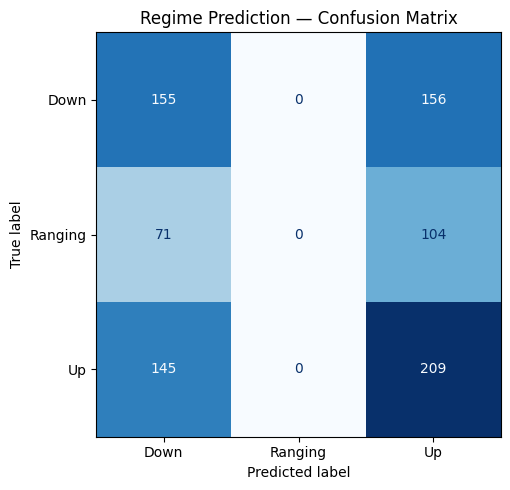

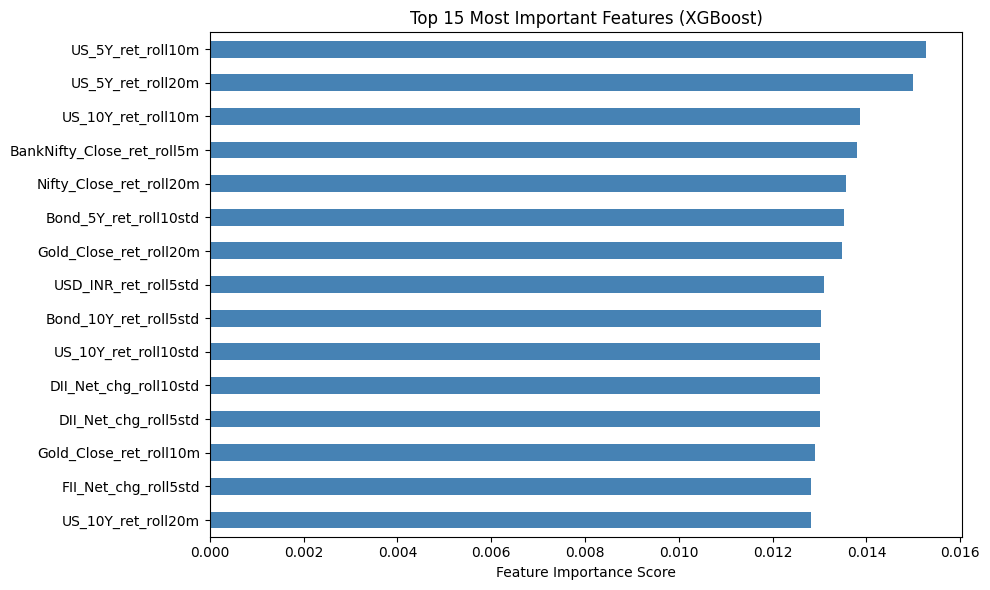


── Top 15 Features ──
  US_5Y_ret_roll10m                             0.0153
  US_5Y_ret_roll20m                             0.0150
  US_10Y_ret_roll10m                            0.0139
  BankNifty_Close_ret_roll5m                    0.0138
  Nifty_Close_ret_roll20m                       0.0136
  Bond_5Y_ret_roll10std                         0.0135
  Gold_Close_ret_roll20m                        0.0135
  USD_INR_ret_roll5std                          0.0131
  Bond_10Y_ret_roll5std                         0.0130
  US_10Y_ret_roll10std                          0.0130
  DII_Net_chg_roll10std                         0.0130
  DII_Net_chg_roll5std                          0.0130
  Gold_Close_ret_roll10m                        0.0129
  FII_Net_chg_roll5std                          0.0128
  US_10Y_ret_roll20m                            0.0128


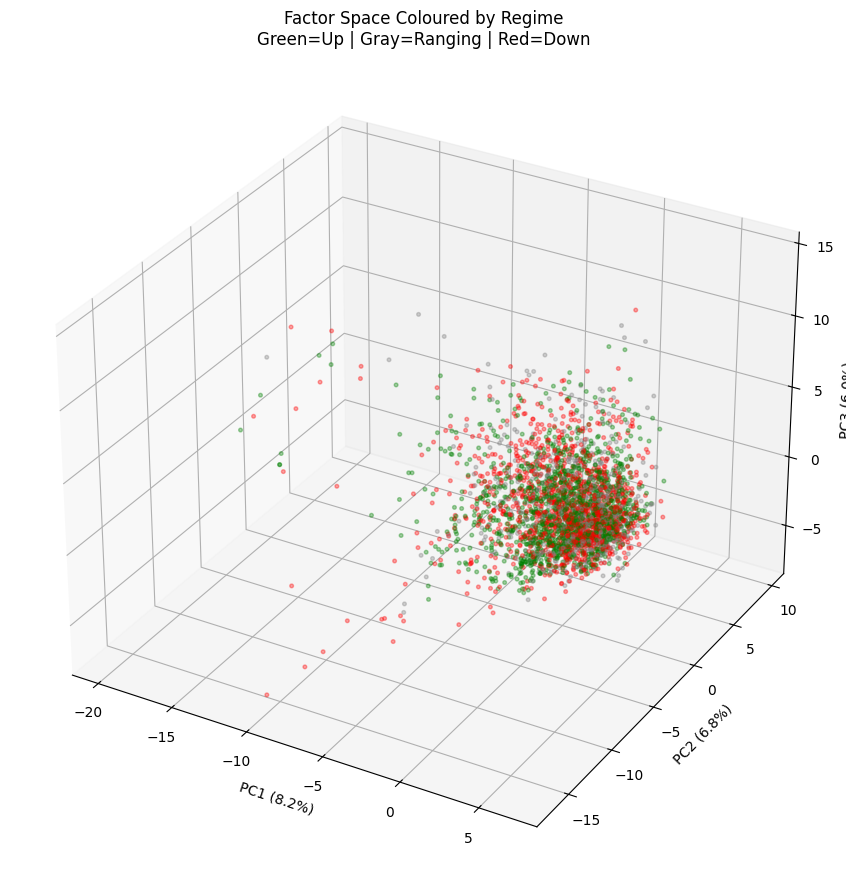


✅ regime_predictions.csv saved
✅ confusion_matrix.png saved
✅ feature_importance.png saved


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# pip install xgboost  ← run this first if not installed

OUT_DIR = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Model data"

# ── STEP 1: Load engineered features ─────────────────────────────────────────

df = pd.read_csv(f"{OUT_DIR}/master_engineered.csv", index_col=0, parse_dates=True)

# Drop old target
df = df.drop(columns=["target"], errors="ignore")

# ── STEP 2: Define REGIME label ───────────────────────────────────────────────
# Use 5-day FORWARD return of ICICI — what happens over next week
# Regime is volatility-adjusted (fair threshold, not arbitrary)

icici_ret = pd.read_csv(f"{OUT_DIR}/master_clean.csv",
                        index_col=0, parse_dates=True)["ICICI_Close_ret"]

# 5-day forward cumulative return
fwd_5d = icici_ret.rolling(5).sum().shift(-5)

# Volatility-adjusted thresholds (rolling 60-day std)
vol_60 = icici_ret.rolling(60).std()
upper  = +0.5 * vol_60   # above this = Trending Up
lower  = -0.5 * vol_60   # below this = Trending Down

# Label: 2 = Up, 1 = Ranging, 0 = Down
def label_regime(fwd, up_thresh, dn_thresh):
    if pd.isna(fwd):
        return np.nan
    if fwd > up_thresh:
        return 2   # Trending Up
    elif fwd < dn_thresh:
        return 0   # Trending Down
    else:
        return 1   # Ranging

regime = pd.Series(index=icici_ret.index, dtype=float)
for date in icici_ret.index:
    if date in fwd_5d.index and date in upper.index:
        regime[date] = label_regime(fwd_5d[date], upper[date], lower[date])

regime = regime.dropna().astype(int)

# ── STEP 3: Align features + labels ──────────────────────────────────────────

common_idx   = df.index.intersection(regime.index)
X            = df.loc[common_idx].drop(columns=["ICICI_Close_ret"], errors="ignore")
X            = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y            = regime.loc[common_idx]

# Class distribution
counts = y.value_counts().sort_index()
labels = {0: "Down", 1: "Ranging", 2: "Up"}
print("── Regime Distribution ──")
for k, v in counts.items():
    print(f"  {labels[k]:>10}: {v:>5} days ({v/len(y)*100:.1f}%)")

# ── STEP 4: Time-aware train/test split ───────────────────────────────────────

split       = int(len(X) * 0.8)
X_train     = X.iloc[:split]
X_test      = X.iloc[split:]
y_train     = y.iloc[:split]
y_test      = y.iloc[split:]

print(f"\nTrain: {X_train.index[0].date()} → {X_train.index[-1].date()}")
print(f"Test : {X_test.index[0].date()}  → {X_test.index[-1].date()}")

# ── STEP 5: Scale ─────────────────────────────────────────────────────────────

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# ── STEP 6: XGBoost Classifier ───────────────────────────────────────────────

model = XGBClassifier(
    n_estimators    = 500,
    max_depth       = 4,        # shallow = less overfit
    learning_rate   = 0.02,
    subsample       = 0.7,
    colsample_bytree= 0.6,
    use_label_encoder=False,
    eval_metric     = "mlogloss",
    random_state    = 42,
    early_stopping_rounds = 30,
)

model.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)

# ── STEP 7: Evaluate ──────────────────────────────────────────────────────────

pred        = model.predict(X_test_sc)
proba       = model.predict_proba(X_test_sc)
acc         = accuracy_score(y_test, pred)

print(f"\n── XGBoost Results ──")
print(f"Overall Accuracy: {acc*100:.2f}%")
print(f"(Baseline = {counts.max()/len(y)*100:.1f}% — always predict majority class)")
print()
print(classification_report(y_test, pred,
                             target_names=["Down", "Ranging", "Up"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred),
    display_labels=["Down", "Ranging", "Up"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Regime Prediction — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# ── STEP 8: Feature Importance ────────────────────────────────────────────────

importance  = pd.Series(model.feature_importances_, index=X.columns)
top15       = importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Most Important Features (XGBoost)")
ax.set_xlabel("Feature Importance Score")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_importance.png", dpi=150)
plt.show()

print("\n── Top 15 Features ──")
for feat, score in top15.items():
    print(f"  {feat:<45} {score:.4f}")

# ── STEP 9: PCA 3D — colour by regime ────────────────────────────────────────

pca     = PCA(n_components=3)
X_pca   = pca.fit_transform(X_train_sc)
exp     = pca.explained_variance_ratio_
palette = {0: "red", 1: "gray", 2: "green"}
colors  = [palette[r] for r in y_train]

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=colors, alpha=0.35, s=7)
ax.set_xlabel(f"PC1 ({exp[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({exp[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({exp[2]*100:.1f}%)")
ax.set_title("Factor Space Coloured by Regime\nGreen=Up | Gray=Ranging | Red=Down")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pca_3d_regime.png", dpi=150)
plt.show()

# ── STEP 10: Save predictions ─────────────────────────────────────────────────

results = pd.DataFrame({
    "actual_regime"   : y_test.map(labels),
    "pred_regime"     : pd.Series(pred, index=y_test.index).map(labels),
    "prob_down"       : proba[:, 0],
    "prob_ranging"    : proba[:, 1],
    "prob_up"         : proba[:, 2],
}, index=y_test.index)

results.to_csv(f"{OUT_DIR}/regime_predictions.csv")
print(f"\n✅ regime_predictions.csv saved")
print(f"✅ confusion_matrix.png saved")
print(f"✅ feature_importance.png saved")

Total features built: 113
Final dataset: 4200 rows × 113 features

Regime distribution:
        Down: 1609 (38.3%)
     Ranging: 819 (19.5%)
          Up: 1772 (42.2%)

── Walk-Forward Validation (5 folds) ──
Fold                    Train                   Test   Accuracy    Dir Acc
---------------------------------------------------------------------------
1       2010-03-30→2012-12-03  2012-12-04→2015-08-10      37.7%      50.7%
2       2010-03-30→2015-08-10  2015-08-11→2018-04-16      41.6%      52.3%
3       2010-03-30→2018-04-16  2018-04-17→2020-12-21      42.6%      57.3%
4       2010-03-30→2020-12-21  2020-12-22→2023-08-28      39.3%      55.7%
5       2010-03-30→2023-08-28  2023-08-29→2026-05-04      35.3%      58.3%

                                                   MEAN      39.3%      54.9%
                                                    STD       2.6%       2.9%

── Final Model ──
              precision    recall  f1-score   support

        Down       0.38      0.60 

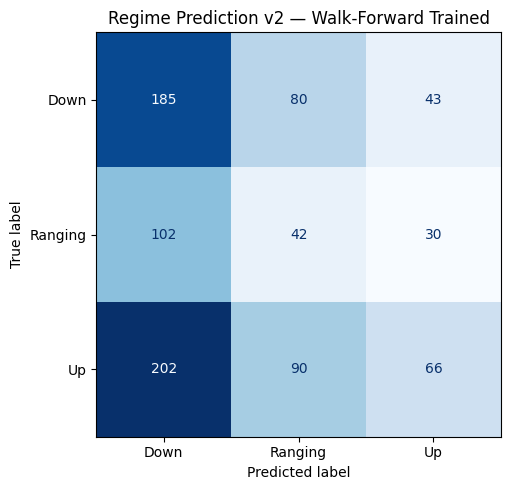

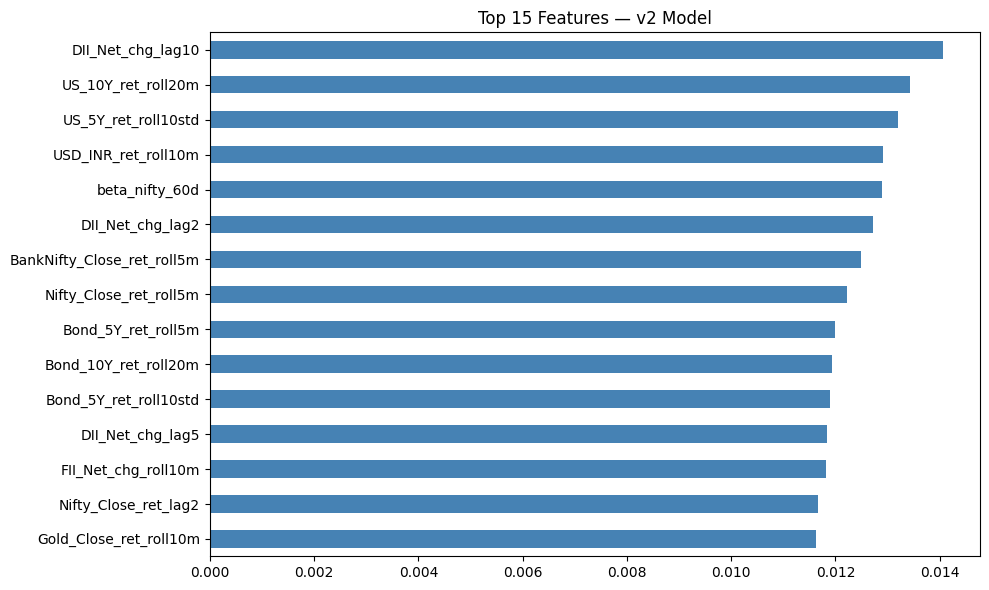


✅ regime_predictions_v2.csv saved

Sample predictions (last 10 days):
             actual predicted  prob_down  prob_ranging   prob_up  confidence
Date                                                                        
2026-04-21     Down      Down   0.337609      0.333864  0.328527    0.337609
2026-04-22     Down      Down   0.344033      0.319873  0.336094    0.344033
2026-04-23     Down        Up   0.335497      0.327543  0.336960    0.336960
2026-04-24     Down      Down   0.335777      0.335243  0.328979    0.335777
2026-04-27     Down        Up   0.327306      0.333864  0.338830    0.338830
2026-04-28     Down   Ranging   0.328520      0.340135  0.331345    0.340135
2026-04-29  Ranging        Up   0.327190      0.335995  0.336815    0.336815
2026-04-30       Up   Ranging   0.327495      0.337789  0.334716    0.337789
2026-05-01  Ranging   Ranging   0.325233      0.340202  0.334566    0.340202
2026-05-04  Ranging   Ranging   0.332421      0.334919  0.332661    0.334919


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, r2_score)
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings("ignore")

OUT_DIR = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Model data"

# ── STEP 1: Load clean data (no fillna(0) this time) ─────────────────────────

clean = pd.read_csv(f"{OUT_DIR}/master_clean.csv", index_col=0, parse_dates=True)
icici_ret = clean["ICICI_Close_ret"]

# ── STEP 2: Rebuild features properly ────────────────────────────────────────

def zscore_roll(series, window=60):
    m = series.shift(1).rolling(window).mean()
    s = series.shift(1).rolling(window).std()
    return (series - m) / (s + 1e-9)

def rolling_beta(y, x, window=60):
    """Rolling beta of y relative to x"""
    cov = y.rolling(window).cov(x)
    var = x.rolling(window).var()
    return (cov / (var + 1e-9)).shift(1)

features = pd.DataFrame(index=clean.index)

daily_cols = [
    "Nifty_Close_ret", "BankNifty_Close_ret", "Gold_Close_ret",
    "USD_INR_ret", "Bond_10Y_ret", "Bond_5Y_ret",
    "US_10Y_ret", "US_5Y_ret", "FII_Net_chg", "DII_Net_chg"
]

slow_cols = [
    "CPI_Index_chg", "WPI_Index_chg", "Trade_Balance_Billion_USD_chg",
    "Repo_Rate_%_chg", "CRR_%_chg", "Real_GDP_YoY_Growth_%_chg",
    "Net Profit (₹ Cr)_chg", "NII (₹ Cr)_chg"
]

# Lags + rolling — forward fill NaN (not zero fill)
for col in daily_cols:
    for lag in [1, 2, 5, 10]:
        features[f"{col}_lag{lag}"] = clean[col].shift(lag)
    for w in [5, 10, 20]:
        features[f"{col}_roll{w}m"] = clean[col].shift(1).rolling(w).mean()
    for w in [5, 10]:
        features[f"{col}_roll{w}std"] = clean[col].shift(1).rolling(w).std()

for col in slow_cols:
    features[col] = clean[col].ffill()   # ← forward fill, not zero fill

# ── STEP 3: NEW — Yield Spread Features ──────────────────────────────────────

features["india_us_10y_spread"] = clean["Bond_10Y_ret"] - clean["US_10Y_ret"]
features["india_us_5y_spread"]  = clean["Bond_5Y_ret"]  - clean["US_5Y_ret"]
features["india_5y_10y_spread"] = clean["Bond_5Y_ret"]  - clean["Bond_10Y_ret"]
features["us_5y_10y_spread"]    = clean["US_5Y_ret"]    - clean["US_10Y_ret"]

# ── STEP 4: NEW — Interaction Features ───────────────────────────────────────

features["usd_bond_stress"]   = zscore_roll(clean["USD_INR_ret"]) * zscore_roll(clean["Bond_10Y_ret"])
features["usd_gold_diverge"]  = zscore_roll(clean["USD_INR_ret"]) * zscore_roll(clean["Gold_Close_ret"])
features["fii_usd_flow"]      = zscore_roll(clean["FII_Net_chg"]) * zscore_roll(clean["USD_INR_ret"])
features["nifty_bond_regime"] = zscore_roll(clean["Nifty_Close_ret"]) * zscore_roll(clean["Bond_10Y_ret"])

# ── STEP 5: NEW — Rolling Beta of ICICI to Nifty + BankNifty ─────────────────

features["beta_nifty_60d"]     = rolling_beta(icici_ret, clean["Nifty_Close_ret"],     60)
features["beta_banknifty_60d"] = rolling_beta(icici_ret, clean["BankNifty_Close_ret"], 60)
features["beta_nifty_20d"]     = rolling_beta(icici_ret, clean["Nifty_Close_ret"],     20)

# ── STEP 6: Composite Regime Indices ─────────────────────────────────────────

features["RiskStress_idx"] = (
    zscore_roll(clean["USD_INR_ret"])
    - zscore_roll(clean["FII_Net_chg"])
    + zscore_roll(clean["Bond_10Y_ret"]).abs()
)
features["MacroHealth_idx"] = (
    - zscore_roll(clean["CPI_Index_chg"])
    + zscore_roll(clean["Real_GDP_YoY_Growth_%_chg"])
    - zscore_roll(clean["Trade_Balance_Billion_USD_chg"])
)
features["Liquidity_idx"] = (
    - zscore_roll(clean["Repo_Rate_%_chg"])
    + zscore_roll(clean["DII_Net_chg"])
    + zscore_roll(clean["FII_Net_chg"])
)
features["Momentum_idx"] = (
    zscore_roll(clean["Nifty_Close_ret"])
    + zscore_roll(clean["BankNifty_Close_ret"])
    - zscore_roll(clean["USD_INR_ret"])
)

print(f"Total features built: {features.shape[1]}")

# ── STEP 7: Build targets — regime + direction + magnitude ────────────────────

fwd_5d  = icici_ret.rolling(5).sum().shift(-5)
vol_60  = icici_ret.rolling(60).std()
upper   = +0.5 * vol_60
lower   = -0.5 * vol_60

def label(fwd, up, dn):
    if pd.isna(fwd): return np.nan
    if fwd > up:  return 2   # Up
    if fwd < dn:  return 0   # Down
    return 1                 # Ranging

regime_raw = pd.Series([
    label(fwd_5d.get(d, np.nan), upper.get(d, np.nan), lower.get(d, np.nan))
    for d in clean.index
], index=clean.index).dropna().astype(int)

direction = (icici_ret.shift(-1) > 0).astype(int)   # 1=up, 0=down
magnitude = icici_ret.shift(-1).abs()                 # size of move

# ── STEP 8: Align everything ──────────────────────────────────────────────────

features = features.replace([np.inf, -np.inf], np.nan)
features = features.ffill().dropna()                 # ← ffill, not fillna(0)

common = features.index\
    .intersection(regime_raw.index)\
    .intersection(direction.index)\
    .intersection(magnitude.index)

X         = features.loc[common]
y_regime  = regime_raw.loc[common]
y_dir     = direction.loc[common]
y_mag     = magnitude.loc[common]

print(f"Final dataset: {X.shape[0]} rows × {X.shape[1]} features")
print(f"\nRegime distribution:")
for k, name in {0:"Down", 1:"Ranging", 2:"Up"}.items():
    n = (y_regime == k).sum()
    print(f"  {name:>10}: {n} ({n/len(y_regime)*100:.1f}%)")

# ── STEP 9: Walk-Forward Validation (5 folds) ─────────────────────────────────

print("\n── Walk-Forward Validation (5 folds) ──")
print(f"{'Fold':<6} {'Train':>22} {'Test':>22} {'Accuracy':>10} {'Dir Acc':>10}")
print("-" * 75)

tscv        = TimeSeriesSplit(n_splits=5)
scaler      = StandardScaler()
fold_accs   = []
fold_dirs   = []
all_preds   = []
all_actual  = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y_regime.iloc[tr_idx], y_regime.iloc[te_idx]
    d_tr, d_te = y_dir.iloc[tr_idx], y_dir.iloc[te_idx]

    sc          = StandardScaler()
    X_tr_sc     = sc.fit_transform(X_tr)
    X_te_sc     = sc.transform(X_te)

    # Class weights — fix Ranging being ignored
    sw = compute_sample_weight("balanced", y_tr)

    clf = XGBClassifier(
        n_estimators      = 400,
        max_depth         = 4,
        learning_rate     = 0.02,
        subsample         = 0.7,
        colsample_bytree  = 0.6,
        eval_metric       = "mlogloss",
        random_state      = 42,
        early_stopping_rounds = 25,
        verbosity         = 0,
    )
    clf.fit(X_tr_sc, y_tr,
            sample_weight   = sw,
            eval_set        = [(X_te_sc, y_te)],
            verbose         = False)

    pred    = clf.predict(X_te_sc)
    acc     = accuracy_score(y_te, pred)

    # Direction accuracy from regime
    pred_dir   = (pred == 2).astype(int)   # Up=1, Down/Ranging=0
    actual_dir = (y_te == 2).astype(int)
    dir_acc    = accuracy_score(actual_dir, pred_dir)

    fold_accs.append(acc)
    fold_dirs.append(dir_acc)
    all_preds.extend(pred)
    all_actual.extend(y_te)

    tr_range = f"{X_tr.index[0].date()}→{X_tr.index[-1].date()}"
    te_range = f"{X_te.index[0].date()}→{X_te.index[-1].date()}"
    print(f"{fold:<6} {tr_range:>22} {te_range:>22} {acc*100:>9.1f}% {dir_acc*100:>9.1f}%")

print(f"\n{'MEAN':>55} {np.mean(fold_accs)*100:>9.1f}% {np.mean(fold_dirs)*100:>9.1f}%")
print(f"{'STD':>55} {np.std(fold_accs)*100:>9.1f}% {np.std(fold_dirs)*100:>9.1f}%")

# ── STEP 10: Final model on 80/20 split ──────────────────────────────────────

split       = int(len(X) * 0.8)
X_tr, X_te  = X.iloc[:split], X.iloc[split:]
y_tr, y_te  = y_regime.iloc[:split], y_regime.iloc[split:]

sc          = StandardScaler()
X_tr_sc     = sc.fit_transform(X_tr)
X_te_sc     = sc.transform(X_te)

sw          = compute_sample_weight("balanced", y_tr)

final_clf   = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.02,
    subsample         = 0.7,
    colsample_bytree  = 0.6,
    eval_metric       = "mlogloss",
    random_state      = 42,
    early_stopping_rounds = 30,
    verbosity         = 0,
)
final_clf.fit(X_tr_sc, y_tr,
              sample_weight = sw,
              eval_set      = [(X_te_sc, y_te)],
              verbose       = False)

pred_final  = final_clf.predict(X_te_sc)
proba_final = final_clf.predict_proba(X_te_sc)

print(f"\n── Final Model ──")
print(classification_report(y_te, pred_final,
                            target_names=["Down", "Ranging", "Up"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, pred_final),
    display_labels=["Down", "Ranging", "Up"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Regime Prediction v2 — Walk-Forward Trained")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_v2.png", dpi=150)
plt.show()

# Feature importance
imp     = pd.Series(final_clf.feature_importances_, index=X.columns)
top15   = imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Features — v2 Model")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_importance_v2.png", dpi=150)
plt.show()

# ── STEP 11: Save predictions ─────────────────────────────────────────────────

labels_map = {0: "Down", 1: "Ranging", 2: "Up"}
results = pd.DataFrame({
    "actual"      : y_te.map(labels_map),
    "predicted"   : pd.Series(pred_final, index=y_te.index).map(labels_map),
    "prob_down"   : proba_final[:, 0],
    "prob_ranging": proba_final[:, 1],
    "prob_up"     : proba_final[:, 2],
    "confidence"  : proba_final.max(axis=1),
}, index=y_te.index)

results.to_csv(f"{OUT_DIR}/regime_predictions_v2.csv")
print(f"\n✅ regime_predictions_v2.csv saved")
print(f"\nSample predictions (last 10 days):")
print(results.tail(10).to_string())